#  Titanic Survival Prediction: XGBoost & Advanced Pipelines

**Цель проекта:** Разработать модель машинного обучения для предсказания выживаемости пассажиров Титаника, используя градиентный бустинг (XGBoost) и профессиональные пайплайны обработки данных.

**Стек технологий:**
*   **Python 3.10+**
*   **XGBoost:** Градиентный бустинг для классификации
*   **Scikit-Learn:** Pipelines, ColumnTransformer, RandomizedSearchCV
*   **Pandas/Numpy:** Обработка данных

**Ключевые особенности решения:**
1.  Автоматическая обработка пропусков и кодирование категорий через `ColumnTransformer`.
2.  Сравнение стратегий поиска гиперпараметров: `GridSearchCV` vs `RandomizedSearchCV`.
3.  Использование `Early Stopping` для предотвращения переобучения.
4.  Финальный пайплайн, готовый к продакшену (без утечек данных).

**Результат:**
*   **ROC-AUC:** 0.8763 ± 0.0238
*   **Accuracy:** 0.88


### Импорт библиоткек

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


### Загрузка данных

В работе будет использоваться датасет Titanic

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [ ]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Пропуски

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Предобработка данных

Удаление явного мусора

In [ ]:
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

#### Разделение на train и test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=24,
    stratify=y
)

In [ ]:
f'Ушло в train = {X_train.shape[0]}, ушло в test = {X_test.shape[0]}'

'Ушло в train = 712, ушло в test = 179'

In [ ]:
pd.Series(y_train).value_counts(normalize=True)

,proportion
Survived,
0,0.616573
1,0.383427


#### ColumnTransformer

"В качестве стратегии предобработки используем ColumnTransformer:


Числовые признаки (Age, Fare): Заполняем пропуски медианой (устойчиво к выбросам) и нормализуем через RobustScaler.


Категориальные (Embarked, Sex): Заполняем модой и кодируем через OneHotEncoder."

In [ ]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        #Числовые: пропуск -> медиана
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), numeric_features),

        #Категориальные: пропук -> мода
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False,
                drop='first'
            ))
        ]), categorical_features)
    ],
    remainder='drop'
)

#### Финальный pipeline предобработки

In [ ]:
pipeline_basic = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
])

In [ ]:
pipeline_basic.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_outpu...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Получаем X_train и X_test обработанные preprocessor для дальнейшего использования там, где pipline не подойдет

In [ ]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

### RandomizedSearchCV / GridSearchCV

In [ ]:
param_distributions = {
    # 1. Архитектура (критично!)
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.05, 0.08, 0.1, 0.12, 0.15, 0.2],

    # 2. Стохастика (стабильность)
    'model__subsample': [0.8, 0.85, 0.9, 0.95],
    'model__colsample_bytree': [0.8, 0.85, 0.9, 0.95],

    # 3. Количество деревьев (диапазон)
    'model__n_estimators': [100, 150, 200, 250, 300],

    # 4. Регуляризация (переобучение)
    'model__reg_alpha': [0, 0.1, 0.3, 0.5],
    'model__reg_lambda': [0.5, 1.0, 1.5, 2.0]
}

In [ ]:
random_search = RandomizedSearchCV(
    pipeline_basic,
    param_distributions=param_distributions,
    n_iter=200,
    cv=StratifiedKFold(5, shuffle=True, random_state=72),
    scoring='roc_auc',
    random_state=72,
    n_jobs=-1,
    verbose=2
)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=72, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                RobustScaler())]),
                                                                               ['Pclass',
                                                                                'Age',
                                                                                'SibSp',
                                                                                'Parch',
                                                                                'Fare']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='mo...
                   param_distributions={'model__colsample_bytree': [0.8, 0.85,
                                                                    0.9, 0.95],
                                        'model__learning_rate': [0.05, 0.08,
                                                                 0.1, 0.12,
                                                                 0.15, 0.2],
                                        'model__max_depth': [3, 4, 5, 6, 7],
                                        'model__n_estimators': [100, 150, 200,
                                                                250, 300],
                                        'model__reg_alpha': [0, 0.1, 0.3, 0.5],
                                        'model__reg_lambda': [0.5, 1.0, 1.5,
                                                              2.0],
                                        'model__subsample': [0.8, 0.85, 0.9,
                                                             0.95]},
                   random_state=72, scoring='roc_auc', verbose=2)

In [ ]:
f'Лучшие параметры = {random_search.best_params_}'

"Лучшие параметры = {'model__subsample': 0.85, 'model__reg_lambda': 2.0, 'model__reg_alpha': 0.5, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.08, 'model__colsample_bytree': 0.9}"

In [ ]:
f'Лучший ROC-AUC на кросс-валидации = {random_search.best_score_:.8f}'

'Лучший ROC-AUC на кросс-валидации = 0.88088092'

Сравнение с GridSearchCV

In [ ]:
param_grid = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__max_depth' : [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.3, 0.5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=pipeline_basic,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_u...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.05, 0.1, 0.3, 0.5],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [50, 100, 150, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='roc_auc')

In [ ]:
f'Лучшие параметры = {grid_search.best_params_}'

"Лучшие параметры = {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}"

In [ ]:
f'Лучший ROC-AUC на кросс-валидации = {grid_search.best_score_:.8f}'

'Лучший ROC-AUC на кросс-валидации = 0.86986726'

In [ ]:
pd.DataFrame({
    'Name search': ['RandomizedSearchCV', 'GridSearchCV'],
    'ROC-AUC': [random_search.best_score_.round(6), grid_search.best_score_.round(6)]
})

,Name search,ROC-AUC
0,RandomizedSearchCV,0.880881
1,GridSearchCV,0.869867


####Анализ и выбор гиперпараметров модели
В ходе экспериментов было проведено сравнение двух стратегий поиска гиперпараметров: RandomizedSearchCV и GridSearchCV.

Результаты оптимизации:
По результатам валидации лучшую производительность продемонстрировала модель с параметрами, найденными через RandomizedSearchCV, достигнув метрики ROC-AUC = 0.8808. Это превосходит результат GridSearchCV (ROC-AUC = 0.8701).

Интерпретация выбора RandomizedSearchCV:
Хотя GridSearchCV гарантированно находит оптимум в заданной сетке, его ограничение заключается в фиксированном наборе значений. RandomizedSearchCV имеет преимущество в исследовании гиперпространства, так как может проверять непрерывные распределения параметров и находить удачные комбинации в промежутках, которые "пропускает" жесткая сетка GridSearch. Более высокий ROC-AUC в данном случае свидетельствует о том, что оптимальные параметры находятся между узлами заданной нами сетки, и случайный поиск смог их обнаружить.

Итоговая конфигурация:
Для финального обучения модели и инференса (предсказания) будут использованы параметры best_params_ из RandomizedSearchCV, так как они обеспечивают наилучшую обобщающую способность модели.



In [ ]:
best_model = random_search.best_estimator_['model']
best_params = random_search.best_params_.copy()
final_params = {k.replace('model__', ''): v for k, v in best_params.items()}
best_params

{'model__subsample': 0.85,
 'model__reg_lambda': 2.0,
 'model__reg_alpha': 0.5,
 'model__n_estimators': 100,
 'model__max_depth': 3,
 'model__learning_rate': 0.08,
 'model__colsample_bytree': 0.9}

### Анализ важности признаков

In [ ]:
feature_importnce = best_model.feature_importances_
features = numeric_features + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features))

In [ ]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importnce
}).sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
5,Sex_male,0.570245
0,Pclass,0.170590
1,Age,0.055274
2,SibSp,0.048878
3,Parch,0.044378
4,Fare,0.042429
7,Embarked_S,0.041733
6,Embarked_Q,0.026473


Визуализация

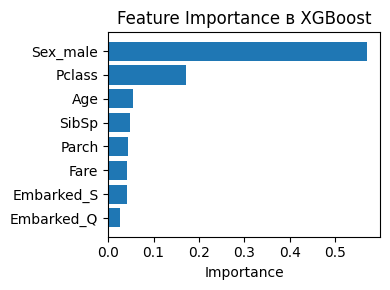

In [ ]:
# Визуализация
plt.figure(figsize=(4, 3))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance в XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Проверка типов важности

In [ ]:
model_for_importance = xgb.XGBClassifier(**final_params)
model_for_importance.fit(X_train_proc , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

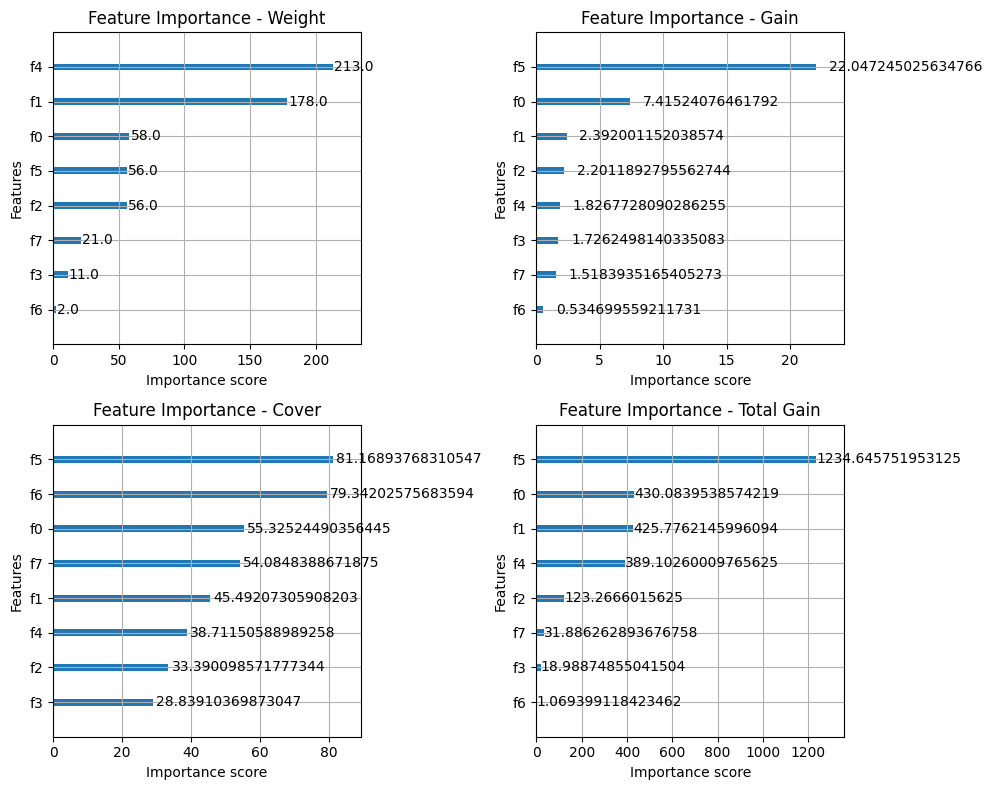

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Weight
xgb.plot_importance(
    model_for_importance,
    importance_type='weight',
    ax=axes[0, 0],
    max_num_features=10
)
axes[0,0].set_title('Feature Importance - Weight')

# Gain
xgb.plot_importance(
    model_for_importance,
    importance_type='gain',
    ax=axes[0, 1],
    max_num_features=10
)
axes[0,1].set_title('Feature Importance - Gain')

# Cover
xgb.plot_importance(
    model_for_importance,
    importance_type='cover',
    ax=axes[1, 0],
    max_num_features=10
)
axes[1,0].set_title('Feature Importance - Cover')

# Total Gain
xgb.plot_importance(
    model_for_importance,
    importance_type='total_gain',
    ax=axes[1, 1],
    max_num_features=10
)
axes[1,1].set_title('Feature Importance - Total Gain')

plt.tight_layout()
plt.show()

### Мониторинг обучения с помощью eval_set

In [ ]:
params_for_eval = final_params.copy()
del params_for_eval['n_estimators']

In [ ]:
model_with_eval = xgb.XGBClassifier(
    ** params_for_eval,
    n_estimators=1000,
    early_stopping_rounds=20,
    random_state=42
)

In [ ]:
eval_set = [(X_train_proc , y_train),(X_test_proc , y_test)]
model_with_eval.fit(
    X_train_proc , y_train,
    eval_set=eval_set,
    verbose=True
)

[0]	validation_0-logloss:0.63278	validation_1-logloss:0.63617
[1]	validation_0-logloss:0.60815	validation_1-logloss:0.61334
[2]	validation_0-logloss:0.58585	validation_1-logloss:0.59178
[3]	validation_0-logloss:0.56289	validation_1-logloss:0.57017
[4]	validation_0-logloss:0.54328	validation_1-logloss:0.55191
[5]	validation_0-logloss:0.52698	validation_1-logloss:0.53829
[6]	validation_0-logloss:0.51361	validation_1-logloss:0.52804
[7]	validation_0-logloss:0.50228	validation_1-logloss:0.51716
[8]	validation_0-logloss:0.49760	validation_1-logloss:0.51365
[9]	validation_0-logloss:0.48638	validation_1-logloss:0.50369
[10]	validation_0-logloss:0.47601	validation_1-logloss:0.49444
[11]	validation_0-logloss:0.46670	validation_1-logloss:0.48668
[12]	validation_0-logloss:0.45830	validation_1-logloss:0.47930
[13]	validation_0-logloss:0.45248	validation_1-logloss:0.47543
[14]	validation_0-logloss:0.44619	validation_1-logloss:0.47090
[15]	validation_0-logloss:0.44057	validation_1-logloss:0.46558
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

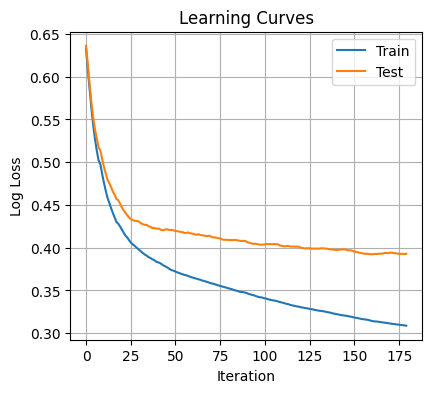

In [ ]:
# Получение результатов
results = model_with_eval.evals_result()

# Визуализация процесса обучения
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Test')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)

In [ ]:
y_pred_eval = model_with_eval.predict(X_test_proc )

In [ ]:
f'Accuracy c early stopping {accuracy_score(y_test, y_pred_eval):.8f}'

'Accuracy c early stopping 0.87150838'

In [ ]:
best_n_estimators = model_with_eval.best_iteration
del final_params['n_estimators']
f'Лучшая итерация = {best_n_estimators}'

'Лучшая итерация = 159'

In [ ]:
final_params

{'subsample': 0.85,
 'reg_lambda': 2.0,
 'reg_alpha': 0.5,
 'max_depth': 3,
 'learning_rate': 0.08,
 'colsample_bytree': 0.9}

## Финальный Pipline

Данные: 891 строк, 7 признаков
Target: Survived
0    0.6162
1    0.3838
Name: proportion, dtype: float64

📊 ПОДРОБНЫЙ ОТЧЁТ:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       110
           1       0.85      0.75      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



 МАТРИЦА ОШИБОК:
[[101   9]
 [ 17  52]]




КРОСС-ВАЛИДАЦИЯ:
   ROC-AUC: 0.8764 ± 0.0244
   Лучший фолд: 0.9117
   Худший фолд: 0.8391






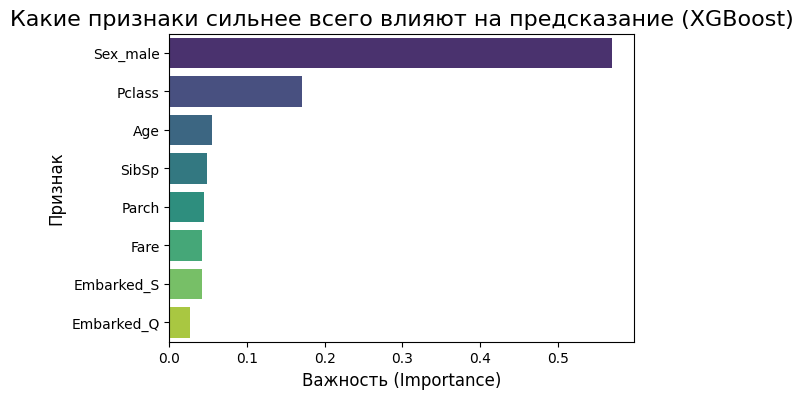

['titanic_xgb_pipeline.joblib']

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import joblib


#Скачивание данных
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#Очистка данных
X = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

print(f"Данные: {X.shape[0]} строк, {X.shape[1]} признаков")
print(f"Target: {y.value_counts(normalize=True).round(4)}")

# Определение признаков
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']


# Предобработка данных
preprocessor = ColumnTransformer(
    transformers=[
        #Числовые: пропуск -> медиана
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), numeric_features),

        #Категориальные: пропук -> мода
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False,
                drop='first'
            ))
        ]), categorical_features)
    ],
    remainder='drop'
)

#Финальная модель
final_model = xgb.XGBClassifier(
    **final_params,
    n_estimators=best_n_estimators,
    n_jobs=-1,
    eval_metric='logloss'
)

# Финальный Pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', final_model)
])

# Финальная кросс-валидация
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    pipeline, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)


pipeline.fit(X_train, y_train)
#Оценки модели
y_pred = pipeline.predict(X_test)
print("\n📊 ПОДРОБНЫЙ ОТЧЁТ:")
print(classification_report(y_test, y_pred))

# 4. Матрица
print("\n\n МАТРИЦА ОШИБОК:")
print(confusion_matrix(y_test, y_pred))

print('\n'*2)
print(f"\nКРОСС-ВАЛИДАЦИЯ:")
print(f"   ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Лучший фолд: {cv_scores.max():.4f}")
print(f"   Худший фолд: {cv_scores.min():.4f}")
print('\n'*3)


# График важности признаков (Feature Importance Bar Plot)
plt.figure(figsize=(6, 4))
plt.title('Какие признаки сильнее всего влияют на предсказание (XGBoost)', fontsize=16)
plt.xlabel('Важность (Importance)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.show()
print('\n'*3)

# Обучение на всех данных
pipeline.fit(X, y)

# Сохранение модели
joblib.dump(best_model, 'titanic_xgb_pipeline.joblib')

In [ ]:
# 8. Демонстрация работы в проде
new_customer = pd.DataFrame({
    'Pclass': [2],
    'Sex': ['female'],  # Женщина
    'Age': [12],
    'SibSp': [1],
    'Parch': [1],
    'Fare': [211.34],
    'Embarked': ['A']
})

proba = pipeline.predict_proba(new_customer)[:, 1]
pred = pipeline.predict(new_customer)[0]

print("\n ПРОДАКШН: Новый пассажир")
print(f"   Вероятность выживания: {proba[0]:.1%}")
print(f"   Предсказание: {'✅ ВЫЖИВЕТ' if pred == 1 else '❌ ПОГИБНЕТ'}")


 ПРОДАКШН: Новый пассажир
   Вероятность выживания: 91.7%
   Предсказание: ✅ ВЫЖИВЕТ
